In [301]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm
import scipy 

from tqdm import tqdm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize
import scipy.stats as stats

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11
from rotation_curve_functions import disk_bulge_vel
from DRP_vel_map_functions import model_vel_map, deproject_spaxel
from dark_matter_mass_v1 import rot_fit_BB
# from DRP_vel_map_plottingFunctions import plot_rot_curve

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/talks/melissinos/'

In [6]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [8]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [9]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [277]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [278]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


## halpha for spiral and elliptical

In [336]:
test_gal = '8997-9102'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, gal_ID, ['sMass'])
# dap_maps = extract_data(VEL_FOLDER, gal_ID, ['star_sigma', 'flux', 'Ha'])


# idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
# flux = dap_maps['mflux']
# ba = master_table['nsa_elpetro_ba'][idx]
# z = master_table['nsa_z'][idx]
# phi = master_table['nsa_elpetro_phi'][idx]
# R90 = master_table['R90_kpc'][idx]
# Mstar = master_table['sphd_M_star'][idx]
# Mstar_R90 = master_table['e_M_star_R90'][idx]


# mHa_vel = ma.array(dap_maps['Ha_vel'], mask=dap_maps['Ha_vel_mask'])


# pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
dap_maps = extract_data(VEL_FOLDER, test_gal, ['star_sigma', 'flux', 'Ha'])

idx = master_table_dict[test_gal]
# sMass = pipe3d_maps['sMass_density']
# sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]


v_sys = master_table['v_sys'][idx]
# i_angle = master_table['ba'][idx]

q0=0.2
cosi2 = (ba**2 - q0**2)/(1 - q0**2)

i_angle = np.arccos(np.sqrt(cosi2))

i_center = master_table['x0'][idx]
j_center = master_table['y0'][idx]
phi = master_table['phi'][idx]
v_max = master_table['v_max'][idx]
r_turn = master_table['r_turn'][idx]
alpha = master_table['alpha'][idx]

masked_ha = ma.array(dap_maps['Ha_vel'], mask=dap_maps['Ha_vel_mask'])

H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
G = 4.30091E-3 # Gravitation constant in units of (km/s)^2 pc/Msun

q0 = 0.2

MANGA_FIBER_DIAMETER = 2*(1/60)*(1/60)*(np.pi/180) # angular fiber diameter (2") in radians
MANGA_SPAXEL_SIZE = 0.5*(1/60)*(1/60)*(np.pi/180)  # spaxel size (0.5") in radians

dist_to_galaxy_Mpc = c*z/H_0
dist_to_galaxy_kpc = dist_to_galaxy_Mpc*1000

pix_scale_factor = dist_to_galaxy_kpc*np.tan(MANGA_SPAXEL_SIZE)

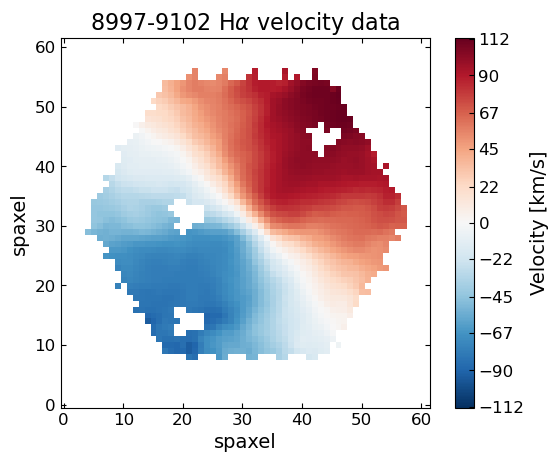

In [288]:
fig, ax = plt.subplots()

max_vel = np.max(ma.abs(mHa_vel))
cbar_ticks = np.linspace(-max_vel+1, max_vel, 11, dtype='int')
# ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=12)

vel_im = ax.imshow( mHa_vel, 
                    cmap='RdBu_r', # 4h 
                    origin='lower', 
                    vmin=-max_vel, 
                    vmax=max_vel)

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'Velocity [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title(test_gal + r' H$\alpha$ velocity data', fontsize=16)


plt.savefig(plot_dir + test_gal + '_Ha_vel.png', bbox_inches='tight', pad_inches=0)

In [290]:
# construct vel model
ha_model = model_vel_map([v_sys, i_angle, i_center, j_center, phi+90, v_max, r_turn, alpha],
                         dap_maps['Ha_vel'].shape,
                         pix_scale_factor,
                         'BB')
mha_model = ma.array(ha_model, mask=dap_maps['Ha_vel_mask'])

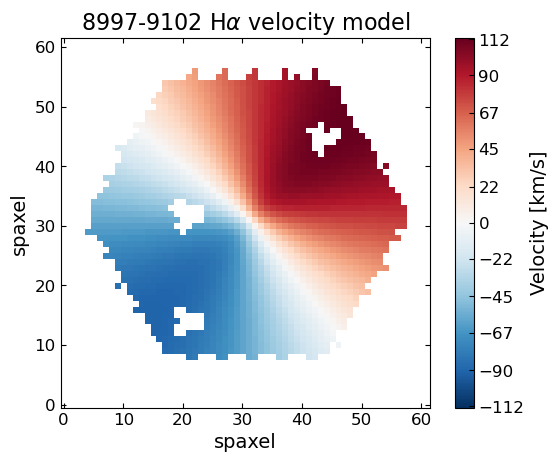

In [291]:
#plot model
fig, ax = plt.subplots()

max_vel = np.max(ma.abs(mha_model))
cbar_ticks = np.linspace(-max_vel+1, max_vel, 11, dtype='int')
# ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=12)

vel_im = ax.imshow( mha_model, 
                    cmap='RdBu_r', # 4h 
                    origin='lower', 
                    vmin=-max_vel, 
                    vmax=max_vel)

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'Velocity [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title(test_gal + r' H$\alpha$ velocity model', fontsize=16)


plt.savefig(plot_dir + test_gal + '_Ha_vel_model.png', bbox_inches='tight', pad_inches=0)

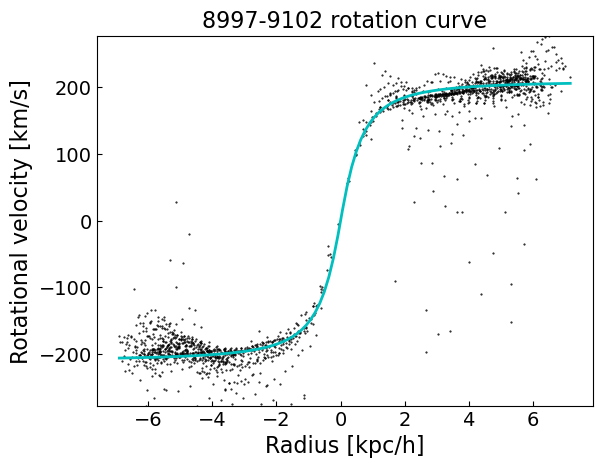

In [332]:
fig, ax = plt.subplots()
vel_array_shape = mHa_vel.shape
phi = phi*np.pi/180

r_deproj = np.zeros(vel_array_shape)
v_deproj = np.zeros(vel_array_shape)

theta = np.zeros(vel_array_shape)

for i in range(vel_array_shape[0]):
    for j in range(vel_array_shape[1]):

        r_deproj[i,j], theta[i,j] = deproject_spaxel((i,j),
                                                     (i_center, j_center),
                                                     phi,
                                                     i_angle)

        ####################################################################
        # Find the sign of r_deproj
        #-------------------------------------------------------------------
        if np.cos(theta[i,j]) < 0:
            r_deproj[i,j] *= -1
        ####################################################################

# Scale radii to convert from spaxels to kpc
r_deproj *= pix_scale_factor

# Deproject velocity values
v_deproj = (mHa_vel - v_sys)/np.abs(np.cos(theta))
v_deproj /= np.sin(i_angle)

# Apply mask to arrays
rm_deproj = ma.array(r_deproj, mask=mHa_vel.mask)
vm_deproj = ma.array(v_deproj, mask=mHa_vel.mask)
############################################################################

r = np.linspace(ma.min(rm_deproj), ma.max(rm_deproj), 100)
v = np.zeros(len(r))

for i in range(0, len(r)):
    v[i] = rot_fit_BB(r[i], [210,
                   r_turn,
                   alpha])


ax.set_title(test_gal + ' rotation curve', fontsize=16)

ax.plot(rm_deproj, vm_deproj, 'k.', markersize=1)
ax.plot(r, v, 'c', linewidth=2)

ax.set_ylim([-1.25*v_max, 1.25*v_max])
ax.tick_params(axis='both', direction='in', labelsize=14)
ax.set_xlabel('Radius [kpc/h]', fontsize=16)
ax.set_ylabel('Rotational velocity [km/s]', fontsize=16)

fig.savefig(plot_dir + test_gal + '_rot_curve.png', bbox_inches='tight')

In [399]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]

Text(0, 0.5, 'spaxel')

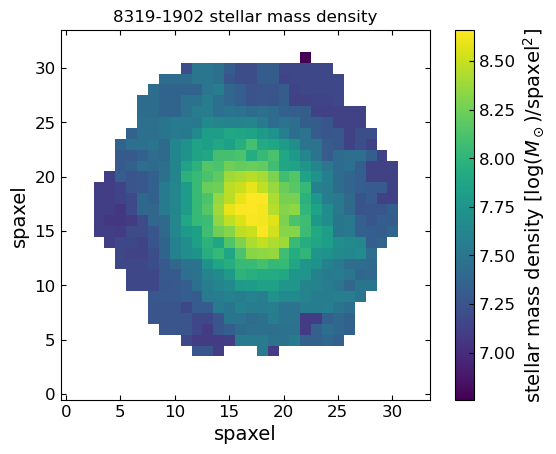

In [400]:
sMass_density = pipe3d_maps['sMass_density']
msMass_density = ma.array(sMass_density, mask=np.isnan(sMass_density))

fig, ax = plt.subplots()

vmax = ma.max(msMass_density)
#cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(gal_ID + ' stellar mass density', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( msMass_density, 
                    cmap='viridis', 
                    origin='lower', 
                    #vmin=0, 
                    #vmax=vmax
                  )

cbar = plt.colorbar( vel_im, ax=ax)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'stellar mass density $[\log(M_\odot) / \rm spaxel^2]$', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)

# plt.savefig( plot_dir + gal_ID + '_sMass_density.png', 
#              format='png', 
#              bbox_inches = 'tight', 
#              pad_inches = 0
#              )

In [401]:
master_table['sphd_

SyntaxError: unterminated string literal (detected at line 1) (3037941597.py, line 1)

In [402]:
np.log10(1000*1000**2)

9.0

In [389]:
master_table['Sigma_disk', 'sphd_Sigma_d']

Sigma_disk,sphd_Sigma_d
float64,float64
300.9007693953248,0.0
293.3478638373148,0.0
1201.0759702017704,0.0
589.741380235529,0.0
1615.3588848989846,0.0
1576.0305400353661,0.0
14633.153273786118,0.0
5006.788331263401,9.754518362123573
4263.988654190836,0.0


In [403]:
mass_table = calc_mass_curve(sMass, sMass_err, flux, ba, phi, z)
rs = np.linspace(np.min(mass_table['radius']), np.max(mass_table['radius']), 1000)
rs = np.linspace(0,4, 1000)
sph = exponential_sphere(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx])
disk = exponential_disk(rs, 10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
sphdisk = exponential_sphere_disk(rs, master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx],
                                  master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
mass_table['M_star_err'] = mass_table['M_star_err'] + np.max(mass_table['M_star'])-2.5

In [404]:
sphdisk

array([0.00000000e+00, 6.42519104e+05, 2.56028244e+06, 5.73869267e+06,
       1.01632765e+07, 1.58196837e+07, 2.26936864e+07, 3.07711778e+07,
       4.00381719e+07, 5.04808017e+07, 6.20853192e+07, 7.48380939e+07,
       8.87256122e+07, 1.03734476e+08, 1.19851404e+08, 1.37063227e+08,
       1.55356890e+08, 1.74719450e+08, 1.95138078e+08, 2.16600052e+08,
       2.39092764e+08, 2.62603712e+08, 2.87120504e+08, 3.12630855e+08,
       3.39122587e+08, 3.66583627e+08, 3.95002010e+08, 4.24365871e+08,
       4.54663452e+08, 4.85883096e+08, 5.18013248e+08, 5.51042456e+08,
       5.84959367e+08, 6.19752726e+08, 6.55411381e+08, 6.91924274e+08,
       7.29280448e+08, 7.67469040e+08, 8.06479283e+08, 8.46300508e+08,
       8.86922138e+08, 9.28333690e+08, 9.70524775e+08, 1.01348510e+09,
       1.05720445e+09, 1.10167271e+09, 1.14687987e+09, 1.19281598e+09,
       1.23947120e+09, 1.28683578e+09, 1.33490003e+09, 1.38365439e+09,
       1.43308934e+09, 1.48319549e+09, 1.53396350e+09, 1.58538412e+09,
      

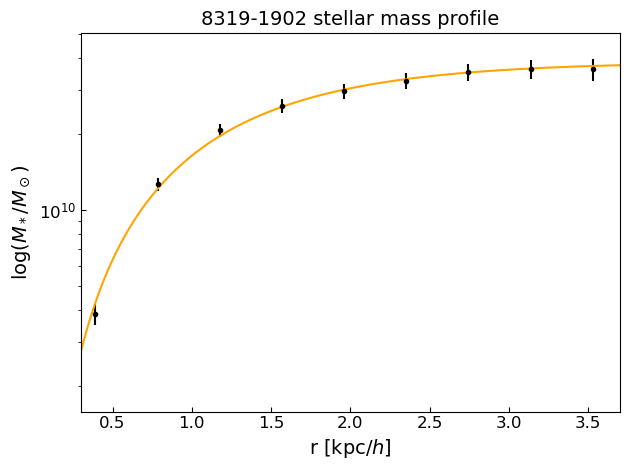

In [410]:
plt.errorbar(mass_table['radius'], 10**mass_table['M_star'], yerr=10**mass_table['M_star_err'], color='k', fmt='.')
# plt.plot(rs, sph, color='dodgerblue', linestyle='--', label='sphere')
# plt.plot(rs, disk, color='crimson', linestyle='--', label='disk')
plt.plot(rs, sphdisk, color='orange')
plt.ylim(10**9.2, 10**10.7)
plt.yscale('log')
plt.xlabel(r'r [kpc/$h$]', fontsize=14)
plt.ylabel(r'$\log(M_*/M_\odot)$',fontsize=14)
# ax[1].legend(loc='lower right', )
plt.tick_params( axis='both', direction='in', labelsize=12)


#R90, M(R90), M*
# plt.axvline(R90, color='k', linestyle=':', label=r'$R_{90}$')
# plt.axhline(10**Mstar_R90, color='k', linestyle='--', label=r'$M_*(R_{90})$')

# plt.axhline(10**Mstar, color='r', label = r'$M_*$')
# plt.legend(fontsize=12)

plt.xlim(0.3, 3.7)

plt.title(gal_ID + ' stellar mass profile', fontsize=14)
plt.tight_layout()
plt.savefig(plot_dir + gal_ID +  '_smass_sphd_fit.png', bbox_inches='tight', pad_inches=0)

1.0

In [55]:
gal_ID = '7975-3703'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, gal_ID, ['sMass'])
dap_maps = extract_data(VEL_FOLDER, gal_ID, ['star_sigma', 'flux', 'Ha'])


# idx = master_table_dict[gal_ID]
# sMass = pipe3d_maps['sMass_density']
# sMass_err = pipe3d_maps['sMass_density_err']
# flux = dap_maps['mflux']
# ba = master_table['nsa_elpetro_ba'][idx]
# z = master_table['nsa_z'][idx]
# phi = master_table['nsa_elpetro_phi'][idx]
# R90 = master_table['R90_kpc'][idx]
# Mstar = master_table['sphd_M_star'][idx]
# Mstar_R90 = master_table['e_M_star_R90'][idx]


mHa_vel = ma.array(dap_maps['Ha_vel'], mask=dap_maps['Ha_vel_mask'])

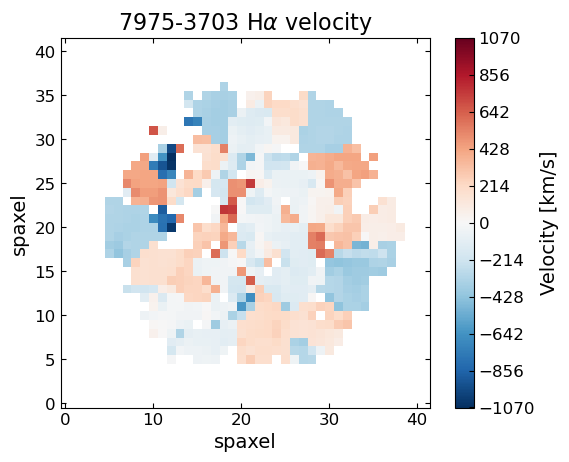

In [59]:
fig, ax = plt.subplots()

max_vel = np.max(ma.abs(mHa_vel))
cbar_ticks = np.linspace(-max_vel+1, max_vel, 11, dtype='int')
# ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=12)

vel_im = ax.imshow( mHa_vel, 
                    cmap='RdBu_r', # 4h 
                    origin='lower', 
                    vmin=-max_vel, 
                    vmax=max_vel)

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'Velocity [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=16)


plt.savefig(plot_dir + gal_ID + '_Ha_vel.png', bbox_inches='tight', pad_inches=0)

In [ ]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]

## expected and observed rot curves

In [89]:
gal_ID = '8997-9102'
idx = master_table_dict[gal_ID]
master_table[idx]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [104]:
rs = np.linspace(0,10,100)
v_obs = master_table['v_max'][idx]*rs/(master_table['r_turn'][idx]**master_table['alpha'][idx] + rs**master_table['alpha'][idx])**(1/master_table['alpha'][idx])
v_exp = disk_bulge_vel(rs, master_table['Sigma_disk'][idx], master_table['R_disk'][idx], master_table['rho_bulge'][idx]/1000**3, master_table['R_bulge'][idx])

/Users/nityaravi/Documents/Github/RotationCurves/spirals/rotation_curve_functions.py:379: RuntimeWarning: invalid value encountered in multiply
  bessel_component = (iv(0, y) * kn(0, y) - iv(1, y) * kn(1, y))
/Users/nityaravi/Documents/Github/RotationCurves/spirals/rotation_curve_functions.py:388: RuntimeWarning: invalid value encountered in divide
  vb_2 = coeff_2 * F / r


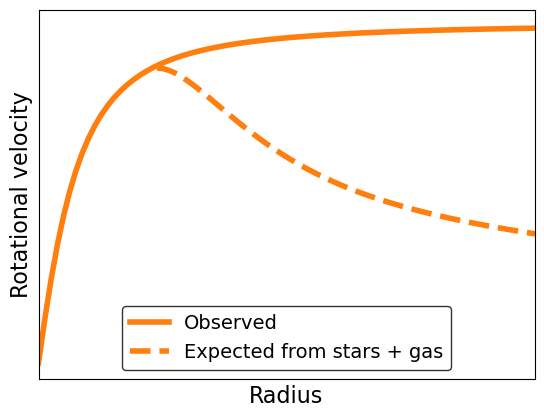

In [144]:
plt.plot(rs,v_obs, color='tab:orange', linewidth=4, label='Observed')
plt.plot(rs[rs>1.1]+0.8, v_exp[rs>1.1]*1.2, linestyle='--', color='tab:orange', linewidth=4, label='Expected from stars + gas')
plt.xlim(0,8)
plt.xlabel('Radius', fontsize=16)
plt.ylabel('Rotational velocity', fontsize=16)
plt.legend(fontsize=14, loc='lower center', facecolor='none', edgecolor='k')
plt.xticks([])
plt.yticks([])
plt.savefig(plot_dir + 'rot_curve.png', transparent=True, bbox_inches='tight')

## BTFR models

In [145]:
vs = np.linspace(1,3,100)

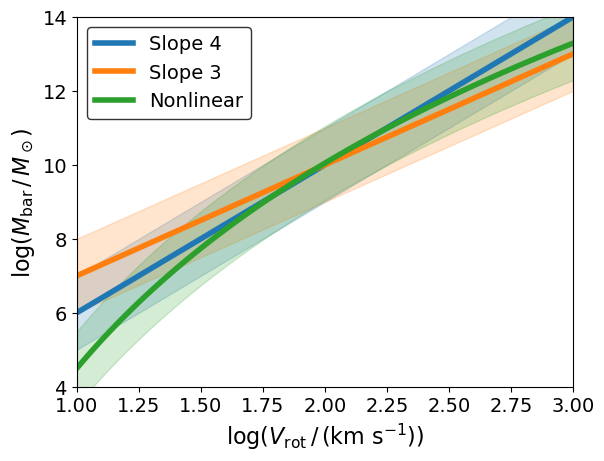

In [190]:
plt.plot(vs, 4*vs + 2, linewidth=4, color='tab:blue', label='Slope 4')
plt.fill_between(vs, 4*vs +3, 4*vs+1, color='tab:blue', alpha=0.2)

plt.plot(vs, 3*vs + 4, linewidth=4, color='tab:orange', label='Slope 3')
plt.fill_between(vs, 3*vs + 5, 3*vs + 3, color='tab:orange', alpha=0.2)


plt.plot(vs, 8*np.log(vs)+4.5, linewidth=4, color='tab:green', label='Nonlinear')
plt.fill_between(vs, 8*np.log(vs)+5.5, 8*np.log(vs)+3.5, color='tab:green', alpha=0.2)

plt.xlabel(r'$\log(V_{\rm rot}\,/\,\rm (km\ s^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm bar}\,/\,M_\odot)$', fontsize=16)

plt.tick_params(labelsize=14)
plt.xlim(1,3)
plt.ylim(4,14)

# legend_elements = [#Line2D([0], [0], marker='o', color='w', label='IllustrisTNG ellipticals',
#                     #      markeredgecolor='sienna', markerfacecolor='none', markersize=6),
#                   Line2D([0], [0], marker='none', color='k', label='BTFR model',
#                           markeredgecolor='none', markerfacecolor='none', linestyle='-', linewidth=4),
#                   # Line2D([0], [0], marker='x', color='w', label='Ellipticals',
#                   #         markeredgecolor='pink', markerfacecolor='pink', markersize=6),
#                   #   Line2D([0], [0], marker='^', color='w', label='Spiral mean',
#                   #         markeredgecolor='navy', markerfacecolor='navy', markersize=6),
#                   #   Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
#                   #         markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
#                 Patch(facecolor='k', alpha=0.2,
#                          label='intrinsic and observational scatter'),
                # ]
plt.legend(fontsize=14, facecolor='none', edgecolor='k')

plt.savefig(plot_dir + 'lcdm_btfr_model_3.png', transparent=True, bbox_inches='tight')

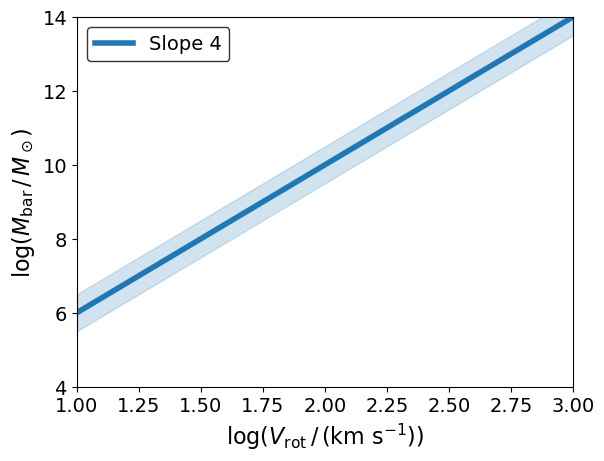

In [191]:
plt.plot(vs, 4*vs + 2, linewidth=4, color='tab:blue', label='Slope 4')
plt.fill_between(vs, 4*vs +2.5, 4*vs+1.5, color='tab:blue', alpha=0.2)


plt.xlabel(r'$\log(V_{\rm rot}\,/\,\rm (km\ s^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm bar}\,/\,M_\odot)$', fontsize=16)

plt.tick_params(labelsize=14)
plt.xlim(1,3)
plt.ylim(4,14)

# legend_elements = [#Line2D([0], [0], marker='o', color='w', label='IllustrisTNG ellipticals',
#                     #      markeredgecolor='sienna', markerfacecolor='none', markersize=6),
#                   Line2D([0], [0], marker='none', color='k', label='BTFR model',
#                           markeredgecolor='none', markerfacecolor='none', linestyle='-', linewidth=4),
#                   # Line2D([0], [0], marker='x', color='w', label='Ellipticals',
#                   #         markeredgecolor='pink', markerfacecolor='pink', markersize=6),
#                   #   Line2D([0], [0], marker='^', color='w', label='Spiral mean',
#                   #         markeredgecolor='navy', markerfacecolor='navy', markersize=6),
#                   #   Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
#                   #         markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
#                 Patch(facecolor='k', alpha=0.2,
#                          label='intrinsic and observational scatter'),
                # ]
plt.legend(fontsize=14, facecolor='none', edgecolor='k')

plt.savefig(plot_dir + 'mond_btfr_model.png', transparent=True, bbox_inches='tight')

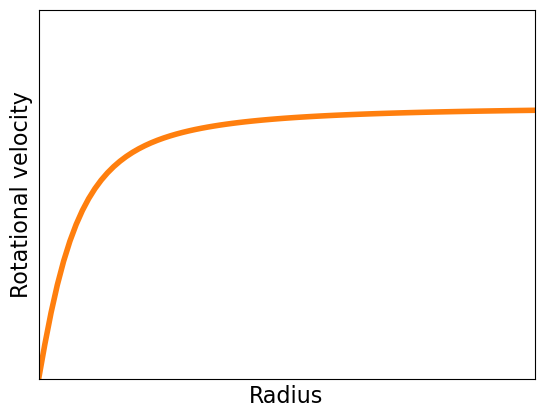

In [196]:
plt.plot(rs,v_obs, color='tab:orange', linewidth=4, label='Observed')
# plt.plot(rs[rs>1.1]+0.8, v_exp[rs>1.1]*1.2, linestyle='--', color='tab:orange', linewidth=4, label='Expected from stars + gas')
plt.xlim(0,8)
plt.ylim(0,300)
plt.xlabel('Radius', fontsize=16)
plt.ylabel('Rotational velocity', fontsize=16)
# plt.legend(fontsize=14, loc='lower center', facecolor='none', edgecolor='k')
plt.xticks([])
plt.yticks([])
plt.savefig(plot_dir + 'rot_curve_paramns.png', transparent=True, bbox_inches='tight')

In [197]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]

In [206]:
mstar_sigma = ma.array(dap_maps['star_sigma'], mask=dap_maps['star_sigma_mask'])

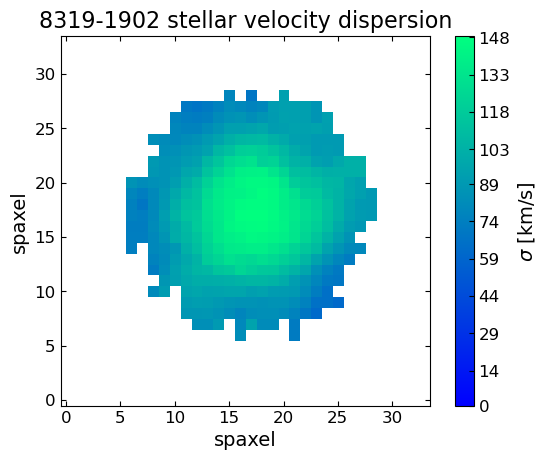

In [211]:
fig, ax = plt.subplots()

max_vel = np.max(ma.abs(mstar_sigma))
cbar_ticks = np.linspace(0, max_vel, 11, dtype='int')
# ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=12)


# plt.imshow(mstar_sigma)
# max_vel = np.max(ma.abs(mHa_vel))
# cbar_ticks = np.linspace(-max_vel+1, max_vel, 11, dtype='int')
# ax.set_title(gal_ID + r' H$\alpha$ velocity', fontsize=12)

vel_im = ax.imshow( mstar_sigma, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=0 ,
                    vmax=ma.max(mstar_sigma))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'$\sigma$ [km/s]', fontsize=14) 

# plt.colorbar()

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title(gal_ID + r' stellar velocity dispersion', fontsize=16)


plt.savefig(plot_dir + gal_ID + '_star_sigma.png', bbox_inches='tight', pad_inches=0)

## BTFR plots

In [214]:
manga_sample = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/BTFR_manga_sample_tng.fits')

In [215]:
i_sample = manga_sample[manga_sample['illustris_match'] >= 0]

In [217]:
HI_spirals = manga_sample[manga_sample['spiral_mask'] == 1]
ellipticals = manga_sample[manga_sample['elliptical_mask'] == 1]
HI_ellipticals = ellipticals[ellipticals['logHI_h'] >= 0]

In [218]:
e_match_mask = np.logical_and(manga_sample['elliptical_mask'] == 1, manga_sample['illustris_match'] >= 0)
s_match_mask = HI_spirals['illustris_match'] >= 0

In [219]:
# recalculate the components

HI_spirals['param_H2'] = np.zeros(len(HI_spirals))
HI_spirals['param_H2_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He90_h'] = np.zeros(len(HI_spirals))


for i in range(len(HI_spirals)):
    
    if HI_spirals['CMD_class'][i] == 1:
        HI_spirals['param_H2'][i] = -0.4*HI_spirals['rabsmag'][i] +1.12
    elif HI_spirals['CMD_class'][i] == 2 or HI_spirals['CMD_class'][i] == 3:
        HI_spirals['param_H2'][i] = -0.27*HI_spirals['rabsmag'][i] + 3.62

    HI_spirals['param_H2_h'][i] = HI_spirals['param_H2'][i] + np.log10(0.7)
    HI_spirals['param_He_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI'][i] + 10**HI_spirals['param_H2'][i])
    HI_spirals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI_R90'][i] + 10**HI_spirals['param_H2'][i])

HI_ellipticals['param_H2'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_H2_h'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_He_h'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_He90_h'] = np.zeros(len(HI_ellipticals))


for i in range(len(HI_ellipticals)):
    
    if HI_ellipticals['CMD_class'][i] == 1:
        HI_ellipticals['param_H2'][i] = -0.4*HI_ellipticals['rabsmag'][i] +1.12
    elif HI_ellipticals['CMD_class'][i] == 2 or HI_ellipticals['CMD_class'][i] == 3:
        HI_ellipticals['param_H2'][i] = -0.27*HI_ellipticals['rabsmag'][i] + 3.62

    HI_ellipticals['param_H2_h'][i] = HI_ellipticals['param_H2'][i] + np.log10(0.7)
    HI_ellipticals['param_He_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_ellipticals['logHI'][i] + 10**HI_ellipticals['param_H2'][i])
    HI_ellipticals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_ellipticals['logHI_R90'][i] + 10**HI_ellipticals['param_H2'][i])


In [221]:
e_manga_mbar = manga_sample[e_match_mask]['sphd_M_star_h']
e_tng_mbar = manga_sample[e_match_mask]['illustris_Mstar_Sal']

In [222]:
s_match = HI_spirals[s_match_mask]
e_match = manga_sample[e_match_mask]

In [223]:
s_tng_mbar = np.zeros(len(s_match))

for i in range(len(s_match)):

    mbar = 0
    
    if s_match['illustris_Mstar_Sal'][i] >= 0:
        mbar += 10**(s_match['illustris_Mstar_Sal'][i])

    if s_match['illustris_MH'][i] >= 0:
        mbar += 10**(s_match['illustris_MH'][i])

    if s_match['illustris_MHe'][i] >= 0:
        mbar += 10**(s_match['illustris_MHe'][i])

    s_tng_mbar[i] = np.log10(mbar)

In [224]:
s_manga_mbar = np.log10(10**s_match['sphd_M_star_h'] + 10**s_match['logHI_h'] + 10**s_match['param_H2_h'] + 10**s_match['param_He_h'])

In [225]:
e_manga_vrot = e_match['v_eff']
e_tng_vrot = e_match['illustris_Vmax']
s_manga_vrot = s_match['v_max']
s_tng_vrot = s_match['illustris_Vmax']

In [254]:
e_veff_ctrs = np.array([9.521275200035577, 9.846632622508253, 10.194584828663874, 10.532589399023939, 10.904307915810673, 11.218711293681476, 11.63924170627309])
e_mvis_avgs = np.array([1.93146628, 2.05958502, 2.20194939, 2.3064407,  2.41078851, 2.50728961,
 2.60615449])
e_mvis_sigs = np.array([0.12309938, 0.10315744, 0.13324442 ,0.10672773 ,0.09246444 ,0.06219667,
 0.06822682])
e_slope = 3.2074901384897756
e_yint = 3.2002594971660683
e_4_yint = 1.3922642642642644

In [266]:
ie_veff_ctrs = np.array([9.510884602864584, 9.843778693560258, 10.19248742233088, 10.535433845642286, 10.905752096603166, 11.223096060586142, 11.644723006657191])
ie_mvis_avgs = np.array([1.93495167 ,2.06429073 ,2.20068182 ,2.310063, 2.41679468, 2.50748088 ,2.6052169])

ie_mvis_sigs = np.array([0.11855719, 0.10317423 ,0.12605655, 0.10782631, 0.09228904, 0.06067895, 0.06971873])
ie_slope = 3.246529709139039
ie_yint = 3.110558254725274
ie_4_yint = 1.7350750750750754*4/5

In [256]:
s_veff_ctrs = np.array([9.500315839090469, 9.843669040354403, 10.183114859572655, 10.523203940253238, 10.847036508075378, 11.175636606619483])
s_mvis_avgs = np.array([2.04014626 ,2.10307171, 2.20735521 ,2.30748056 ,2.3831924, 2.48453014])

s_mvis_sigs = np.array([0.14907962, 0.14784598 ,0.13436233 ,0.119127, 0.09415548, 0.12346181])

s_slope = 3.718348593008421
s_yint = 1.9777690052664552
s_4_yint = 1.33784984984985

In [257]:
is_veff_ctrs = np.array([9.419360755147713, 9.826612954324961, 10.166558551811335, 10.52367338772025, 10.877072091468285])
is_mvis_avgs = np.array([2.00479613, 2.09205258 ,2.18577145 ,2.29055355 ,2.35373974])


is_mvis_sigs = np.array([0.04551576, 0.04065444, 0.04541586 ,0.04129275 ,0.04394884])

is_slope = 4.02172119755156
is_yint = 1.3765441725712182
is_4_yint = 1.4195555555555557

In [247]:
vs = np.linspace(0,4,100)

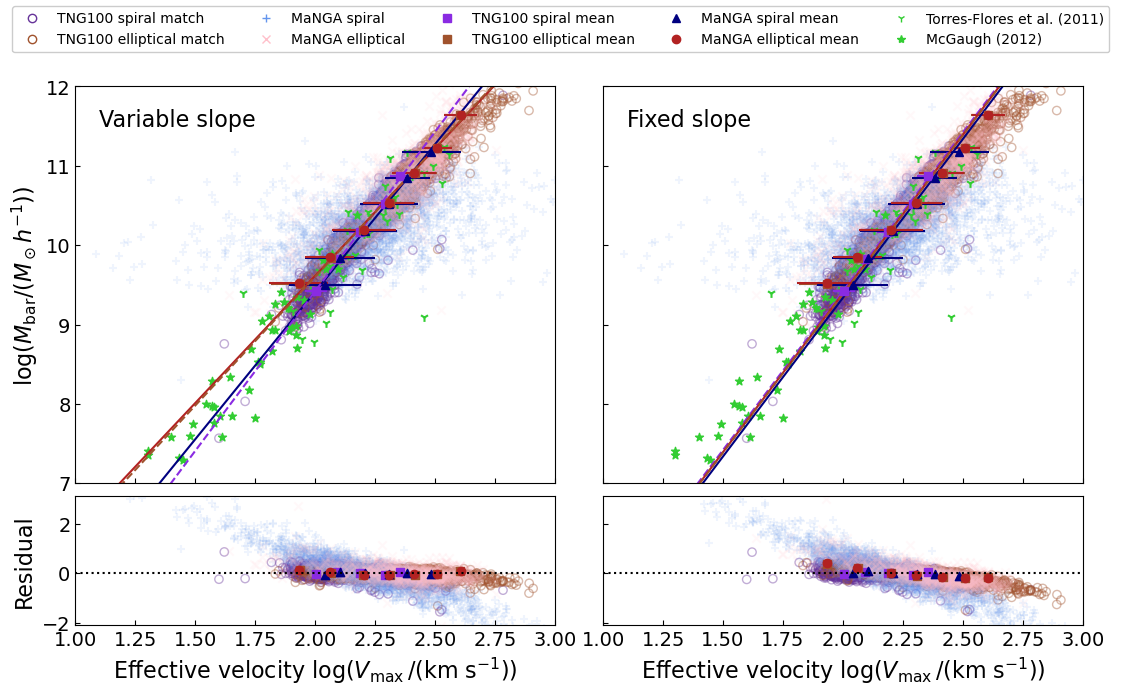

In [279]:
fig, ax  = plt.subplots(2,2, figsize=(13,7), sharex=True, height_ratios=(4,1.3), sharey='row')

# fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(4,1.3, 4), figsize=(6.4,12))


for i in range(2):

    ax[0,i].scatter(np.log10(s_tng_vrot), s_tng_mbar, marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4, label='Spirals')
    ax[0,i].scatter(np.log10(e_tng_vrot), e_tng_mbar, marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
    ax[0,i].scatter(np.log10(s_manga_vrot), s_manga_mbar, marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')
    
    ax[0,i].scatter(np.log10(e_manga_vrot), e_manga_mbar, marker='x', color='pink', alpha=0.1, label='Ellipticals')


    ax[0,i].errorbar(is_mvis_avgs, is_veff_ctrs, xerr=is_mvis_sigs, linestyle='none',
                marker='s', color='blueviolet')
    ax[0,i].errorbar(ie_mvis_avgs, ie_veff_ctrs, xerr=ie_mvis_sigs, linestyle='none',
                marker='s', color='sienna')
    ax[0,i].errorbar(s_mvis_avgs, s_veff_ctrs, xerr=s_mvis_sigs, linestyle='none',
                marker='^', color='navy')
    ax[0,i].errorbar(e_mvis_avgs, e_veff_ctrs, xerr=e_mvis_sigs, linestyle='none',
                marker='o', color='firebrick')
    ax[0,i].set_xlim(1,3)
    ax[0,i].set_ylim(7,12)
    ax[0,i].tick_params( axis='both', direction='in', labelsize=14)
    ax[1,i].tick_params( axis='both', direction='in', labelsize=14)

    ax[1,i].set_xlabel(r'Effective velocity $\log(V_{\rm max}\,/(\text{km s}^{-1}))$', fontsize=16)

    ax[0,i].scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
    ax[0,i].scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')





ax[0,0].plot(vs, vs*s_slope + s_yint, color='navy')
ax[0,0].plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
ax[0,0].plot(vs, vs*e_slope + e_yint, color='firebrick')
ax[0,0].plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')

ms=np.linspace(5,15,100)

ax[0,1].plot(vs, vs*4+s_4_yint, color='navy')
ax[0,1].plot(vs, vs*4 + is_4_yint, color='blueviolet',linestyle='--')
ax[0,1].plot(vs, vs*4 + e_4_yint, color='firebrick')
ax[0,1].plot(vs, vs*4 + ie_4_yint, color='sienna', linestyle='--')

ax[0,0].set_ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='TNG100 spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='TNG100 elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='TNG100 spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='TNG100 elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  
                  Line2D([0], [0], marker='1', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),
                  
                  Line2D([0], [0], marker='*', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),]

fig.legend(handles=legend_elements, loc='upper center', framealpha=1, ncols=5)
fig.subplots_adjust(wspace=0.1, hspace=0.05)


ax[0,0].text(1.1,11.5, 'Variable slope', fontsize=16)
ax[0,1].text(1.1,11.5, 'Fixed slope', fontsize=16)


ax[1,0].scatter(np.log10(s_tng_vrot), s_tng_mbar-(np.log10(s_tng_vrot)*is_slope + is_yint), marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4,)
ax[1,0].scatter(np.log10(e_tng_vrot), e_tng_mbar-(np.log10(e_tng_vrot)*ie_slope + ie_yint), marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
ax[1,0].scatter(np.log10(s_manga_vrot), s_manga_mbar-(np.log10(s_manga_vrot)*s_slope + s_yint), marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

ax[1,0].scatter(np.log10(e_manga_vrot), e_manga_mbar-(np.log10(e_manga_vrot)*e_slope + e_yint), marker='x', color='pink', alpha=0.1, label='Ellipticals')



ax[1,0].scatter(is_mvis_avgs, is_veff_ctrs-(is_mvis_avgs*is_slope + is_yint), marker='s', color='blueviolet')
ax[1,0].scatter(ie_mvis_avgs, ie_veff_ctrs-(ie_mvis_avgs*ie_slope + ie_yint), marker='s', color='sienna')
ax[1,0].scatter(s_mvis_avgs, s_veff_ctrs-(s_mvis_avgs*s_slope + s_yint), marker='^', color='navy')

ax[1,0].scatter(e_mvis_avgs, e_veff_ctrs-(e_mvis_avgs*e_slope + e_yint), marker='o', color='firebrick')




ax[1,1].scatter(np.log10(s_tng_vrot), s_tng_mbar-(np.log10(s_tng_vrot)*4 +is_4_yint), marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4,)
ax[1,1].scatter(np.log10(e_tng_vrot), e_tng_mbar-(np.log10(e_tng_vrot)*4 + ie_4_yint), marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
ax[1,1].scatter(np.log10(s_manga_vrot), s_manga_mbar-(np.log10(s_manga_vrot)*4 + s_4_yint), marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

ax[1,1].scatter(np.log10(e_manga_vrot), e_manga_mbar-(np.log10(e_manga_vrot)*4 + e_4_yint), marker='x', color='pink', alpha=0.1, label='Ellipticals')



ax[1,1].scatter(is_mvis_avgs, is_veff_ctrs-(is_mvis_avgs*4 +is_4_yint), marker='s', color='blueviolet')
ax[1,1].scatter(ie_mvis_avgs, ie_veff_ctrs-(ie_mvis_avgs*4 +ie_4_yint), marker='s', color='sienna')
ax[1,1].scatter(s_mvis_avgs, s_veff_ctrs-(s_mvis_avgs*4 + s_4_yint), marker='^', color='navy')

ax[1,1].scatter(e_mvis_avgs, e_veff_ctrs-(e_mvis_avgs*4 + e_4_yint), marker='o', color='firebrick')







ax[1,0].axhline(0, linestyle=':', color='k')
# ax[1,0].set_ylim(-2.1,2.1)
ax[1,1].axhline(0, linestyle=':', color='k')
ax[1,1].set_ylim(-2.1,3.1)
ax[1,0].set_ylabel('Residual', fontsize=16)
# plt.tight_layout()
fig.subplots_adjust(hspace=0.05)
# fig.subplots_adjust(wspace=0.1)

plt.savefig(plot_dir + 'BTFR_9.png', bbox_inches='tight')